# Resident case risk — elevated clinical risk tier (CRISP-DM / IS 455)

**Business question:** Staff need to know which girls may be **struggling** so they can prioritize counseling, home visits, and intervention planning. This pipeline estimates **elevated case risk** (High / Critical `current_risk_level`) using **structured intake fields** and **longitudinal activity** from process recordings, home visitations, education, health, and intervention plans.

**Folder:** `ml-pipelines/resident_case_progress/`  
**Serialized model:** `serialized_models/resident_elevated_risk_pipeline.joblib`  
**Shared deps:** `../requirements.txt` (parent `ml-pipelines/`)

**Data:** `../../data/lighthouse_csv_v7/` relative to this folder; the setup cell resolves `REPO_ROOT` from cwd (repo root, `ml-pipelines/`, or `resident_case_progress/`).

**Related pipeline:** donor churn — `../donor_retention/donor_retention_churn.ipynb`.

**Ethics:** Scores are **decision support**, not replacements for social-worker judgment. Outputs belong in **authenticated staff-only** systems; do not use for automated removal of services without review.

This notebook mirrors the **donor retention** pipeline structure: problem framing → data understanding → preparation → exploration → predictive + explanatory models → evaluation (CV + holdout) → feature selection → deployment notes (Ch. 17).

## Formal rubric (sections 1–6) — quick map
1. **Problem framing** — Phase 1 below (predictive vs explanatory, stakeholders, costs of errors).  
2. **Data acquisition / EDA / prep** — Phases 2–4; multi-table joins and leakage-safe windows documented there.  
3. **Modeling & feature selection** — Phase 5 (logistic + ensembles, CV tuning).  
4. **Evaluation & interpretation** — Phase 6 (holdout, metrics, business reading of FP/FN).  
5. **Causal & relationships** — Phase narrative + logistic interpretation: **associational**, not causal without RCT.  
6. **Deployment** — `serialized_models/resident_elevated_risk_pipeline.joblib` + metadata; integrate via `ml_backend_export` into `backend/Intex.API/App_Data/ml/` and .NET `Ml*` resident endpoints / admin UI (same pattern as reintegration readiness).

## Phase 1 — Business understanding (Ch. 1)

**Goal:** Flag residents whose **recorded risk tier** is **High** or **Critical** so supervisors can allocate scarce social-work time and review intervention plans.

- **Predictive emphasis:** Rank residents by estimated probability of **elevated risk**; validate with held-out data and CV.
- **Explanatory emphasis:** **Logistic regression** coefficients describe **associations** between service-activity patterns and risk tier in this snapshot — **not** causal effects (unmeasured confounders, label set by staff judgment).

**Success metrics:** ROC-AUC, precision/recall at a default threshold; interpret confusion matrix as **missed high-risk girl** (false negative) vs **unnecessary escalation** (false positive).

**Label `elevated_risk = 1`:** `current_risk_level` ∈ {`High`, `Critical`} on the resident master record.

**Feature timing (leakage control):** We set an **observation date** from the latest dated activity in case-management tables, then use only events in a **365-day window ending 30 days before** that date for aggregates. The **30-day gap** reduces same-day circularity (sessions informing the same week’s risk update). **Limitation:** Risk tier in the export may still reflect recent events; we state this honestly in the narrative section.

### IS 455 lifecycle checklist

| Stage | Coverage |
|-------|-----------|
| Framing | Above + predictive vs explanatory |
| Data prep | Multi-table joins, reproducible windows |
| Exploration | Distributions, correlations |
| Modeling | Logistic (explain) + trees/ensembles (predict) |
| Evaluation | Stratified split, CV for model pick, business readout, fairness slice |
| Feature selection | Importances + `SelectFromModel` |
| Deployment | `joblib` + integration bullets |

## Phase 2 — Data understanding (Ch. 2, 6, 8)

| Table | Use |
|-------|-----|
| `residents` | Outcome (`current_risk_level`), intake demographics, case category, initial risk, safehouse |
| `process_recordings` | Session counts, concerns/progress flags, duration, session type |
| `home_visitations` | Visit counts, outcomes, safety / cooperation signals |
| `education_records` | Attendance, progress % |
| `health_wellbeing_records` | Scores, checkups |
| `intervention_plans` | Plan status mix by category |
| `safehouses` | Optional region context |

Free-text narrative fields are excluded from modeling inputs to reduce PII surface.

In [1]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 50)

def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for d in [p, *p.parents]:
        if (d / "ml-pipelines").is_dir() and (d / "data" / "lighthouse_csv_v7").is_dir():
            return d
    raise FileNotFoundError(
        "Could not find repo root (need ml-pipelines/ and data/lighthouse_csv_v7/). "
        f"cwd={p}"
    )

REPO_ROOT = _find_repo_root(Path.cwd())
ML_PIPELINES_DIR = REPO_ROOT / "ml-pipelines"
DATA_DIR = REPO_ROOT / "data" / "lighthouse_csv_v7"
if not DATA_DIR.is_dir():
    raise FileNotFoundError(f"Missing data directory: {DATA_DIR}")

SERIALIZED_DIR = ML_PIPELINES_DIR / "resident_case_progress" / "serialized_models"
SERIALIZED_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR:", DATA_DIR)
print("SERIALIZED_DIR:", SERIALIZED_DIR)

REPO_ROOT: /Users/jooyoung/Downloads/intex2026/WinterIntex4-5
DATA_DIR: /Users/jooyoung/Downloads/intex2026/WinterIntex4-5/data/lighthouse_csv_v7
SERIALIZED_DIR: /Users/jooyoung/Downloads/intex2026/WinterIntex4-5/ml-pipelines/resident_case_progress/serialized_models


In [2]:
def load_case_tables(data_dir: Path) -> dict[str, pd.DataFrame]:
    out = {}
    for name in [
        "residents",
        "process_recordings",
        "home_visitations",
        "education_records",
        "health_wellbeing_records",
        "intervention_plans",
        "safehouses",
    ]:
        fp = data_dir / f"{name}.csv"
        out[name] = pd.read_csv(fp) if fp.exists() else pd.DataFrame()
    r = out["residents"]
    if not r.empty and "date_of_admission" in r.columns:
        r["date_of_admission"] = pd.to_datetime(r["date_of_admission"], errors="coerce")
    pr = out["process_recordings"]
    if not pr.empty and "session_date" in pr.columns:
        pr["session_date"] = pd.to_datetime(pr["session_date"], errors="coerce")
    hv = out["home_visitations"]
    if not hv.empty and "visit_date" in hv.columns:
        hv["visit_date"] = pd.to_datetime(hv["visit_date"], errors="coerce")
    ed = out["education_records"]
    if not ed.empty and "record_date" in ed.columns:
        ed["record_date"] = pd.to_datetime(ed["record_date"], errors="coerce")
    hw = out["health_wellbeing_records"]
    if not hw.empty and "record_date" in hw.columns:
        hw["record_date"] = pd.to_datetime(hw["record_date"], errors="coerce")
    ip = out["intervention_plans"]
    if not ip.empty and "created_at" in ip.columns:
        ip["created_at"] = pd.to_datetime(ip["created_at"], errors="coerce")
    return out


tabs = load_case_tables(DATA_DIR)
for k, v in tabs.items():
    print(f"{k:28} {v.shape}")

residents                    (60, 49)
process_recordings           (2819, 15)
home_visitations             (1337, 14)
education_records            (534, 10)
health_wellbeing_records     (534, 14)
intervention_plans           (180, 11)
safehouses                   (9, 13)


In [3]:
res = tabs["residents"].copy()
pr = tabs["process_recordings"].copy()
hv = tabs["home_visitations"].copy()
ed = tabs["education_records"].copy()
hw = tabs["health_wellbeing_records"].copy()
ip = tabs["intervention_plans"].copy()
houses = tabs["safehouses"].copy()

dates = []
for df, col in [(pr, "session_date"), (hv, "visit_date"), (ed, "record_date"), (hw, "record_date")]:
    if col in df.columns and not df[col].dropna().empty:
        dates.append(df[col].max())
obs_date = max(dates) if dates else pd.Timestamp.today()
gap_days = 30
feature_end = obs_date - pd.Timedelta(days=gap_days)
feature_start = feature_end - pd.Timedelta(days=365)

print("Observation date (max activity):", obs_date.date())
print("Feature window (exclusive 30d gap before obs):", feature_start.date(), "→", feature_end.date())

RISK_ORD = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
res = res[res["current_risk_level"].notna()].copy()
res["elevated_risk"] = res["current_risk_level"].isin(["High", "Critical"]).astype(int)
res["initial_risk_ord"] = res["initial_risk_level"].map(RISK_ORD)

print("Residents with label:", len(res))
print(res["elevated_risk"].value_counts().sort_index())
print("Elevated rate:", round(res["elevated_risk"].mean(), 3))

Observation date (max activity): 2027-02-02
Feature window (exclusive 30d gap before obs): 2026-01-03 → 2027-01-03
Residents with label: 60
elevated_risk
0    54
1     6
Name: count, dtype: int64
Elevated rate: 0.1


### Exploration (Ch. 6, 8)

Distributions of the outcome, case mix, and raw activity volumes before feature matrices.

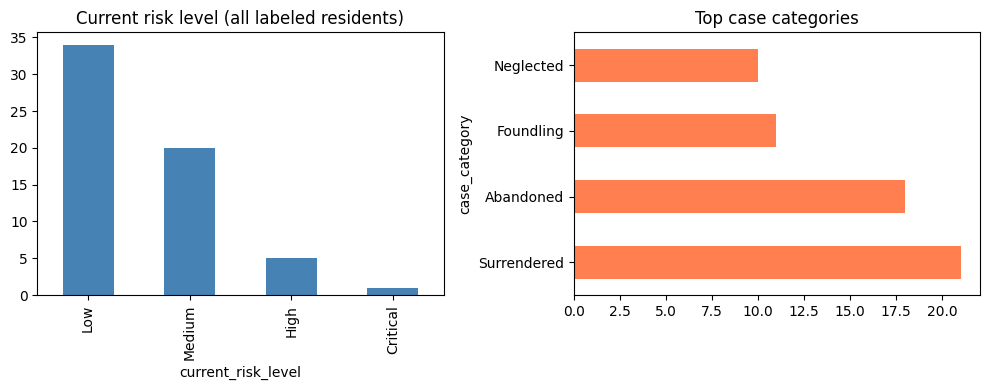

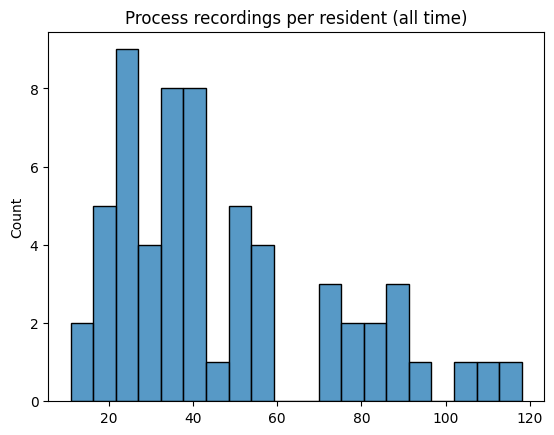

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
res["current_risk_level"].value_counts().reindex(["Low", "Medium", "High", "Critical"]).plot(kind="bar", ax=ax[0], color="steelblue")
ax[0].set_title("Current risk level (all labeled residents)")
res["case_category"].value_counts().head(8).plot(kind="barh", ax=ax[1], color="coral")
ax[1].set_title("Top case categories")
plt.tight_layout()
plt.show()

if not pr.empty:
    sns.histplot(pr.groupby("resident_id").size(), bins=20, kde=False)
    plt.title("Process recordings per resident (all time)")
    plt.show()

## Phase 3 — Data preparation (Ch. 2–4, 7)

Build **resident-level** rows: static intake + **windowed** aggregates. Numeric booleans from `residents` subcategory flags are cast to int. **Length of stay** string parsed for approximate years (rough feature).

X shape: (60, 33) positive rate: 0.1


,resident_id,elevated_risk,initial_risk_ord,stay_years_approx,pr_sessions_prior,pr_mean_duration,pr_concern_rate,pr_progress_rate
0,1,1,4,2.0,7.0,57.857143,0.285714,1.0
1,2,0,2,1.0,NaN,NaN,NaN,NaN
2,3,0,2,1.0,5.0,80.600000,0.000000,1.0
3,4,0,3,1.0,9.0,75.888889,0.222222,1.0
4,5,0,2,0.0,NaN,NaN,NaN,NaN


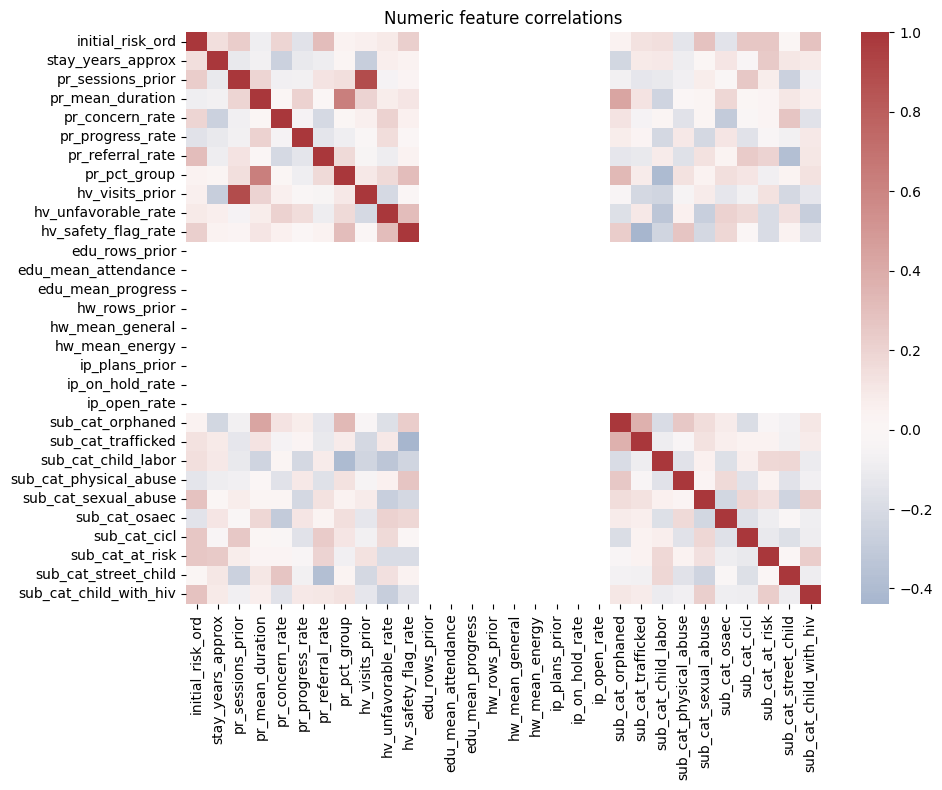

In [5]:
def windowed(df, date_col, left, right):
    return df[(df[date_col] > left) & (df[date_col] <= right)]


pr_w = windowed(pr, "session_date", feature_start, feature_end)
hv_w = windowed(hv, "visit_date", feature_start, feature_end)
ed_w = windowed(ed, "record_date", feature_start, feature_end)
hw_w = windowed(hw, "record_date", feature_start, feature_end)
ip_w = windowed(ip, "created_at", feature_start, feature_end)

# Process recording aggregates
if not pr_w.empty:
    pr_feat = pr_w.groupby("resident_id").agg(
        pr_sessions_prior=("recording_id", "count"),
        pr_mean_duration=("session_duration_minutes", lambda s: pd.to_numeric(s, errors="coerce").mean()),
        pr_concern_rate=("concerns_flagged", lambda s: s.astype(bool).mean()),
        pr_progress_rate=("progress_noted", lambda s: s.astype(bool).mean()),
        pr_referral_rate=("referral_made", lambda s: s.astype(bool).mean()),
        pr_pct_group=("session_type", lambda s: (s.astype(str).str.lower() == "group").mean()),
    ).reset_index()
else:
    pr_feat = (
        res[["resident_id"]]
        .assign(
            pr_sessions_prior=0,
            pr_mean_duration=0.0,
            pr_concern_rate=0.0,
            pr_progress_rate=0.0,
            pr_referral_rate=0.0,
            pr_pct_group=0.0,
        )
    )

# Home visits
if not hv_w.empty:
    unfav = hv_w["visit_outcome"].astype(str).str.contains("Unfavorable|Needs Improvement", case=False, na=False)
    hv_feat = hv_w.assign(_unfav=unfav).groupby("resident_id").agg(
        hv_visits_prior=("visitation_id", "count"),
        hv_unfavorable_rate=("_unfav", "mean"),
        hv_safety_flag_rate=("safety_concerns_noted", lambda s: s.astype(bool).mean()),
    ).reset_index()
else:
    hv_feat = res[["resident_id"]].assign(hv_visits_prior=0, hv_unfavorable_rate=0.0, hv_safety_flag_rate=0.0)

# Education
if not ed_w.empty:
    ed_feat = ed_w.groupby("resident_id").agg(
        edu_rows_prior=("education_record_id", "count"),
        edu_mean_attendance=("attendance_rate", lambda s: pd.to_numeric(s, errors="coerce").mean()),
        edu_mean_progress=("progress_percent", lambda s: pd.to_numeric(s, errors="coerce").mean()),
    ).reset_index()
else:
    ed_feat = res[["resident_id"]].assign(
        edu_rows_prior=0, edu_mean_attendance=0.0, edu_mean_progress=0.0
    )

# Health
if not hw_w.empty:
    hw_feat = hw_w.groupby("resident_id").agg(
        hw_rows_prior=("health_record_id", "count"),
        hw_mean_general=("general_health_score", lambda s: pd.to_numeric(s, errors="coerce").mean()),
        hw_mean_energy=("energy_level_score", lambda s: pd.to_numeric(s, errors="coerce").mean()),
    ).reset_index()
else:
    hw_feat = res[["resident_id"]].assign(
        hw_rows_prior=0, hw_mean_general=0.0, hw_mean_energy=0.0
    )

# Intervention plans
if not ip_w.empty:
    st = ip_w["status"].astype(str).str.lower()
    ip_feat = ip_w.assign(_hold=st.eq("on hold"), _open=st.eq("open")).groupby("resident_id").agg(
        ip_plans_prior=("plan_id", "count"),
        ip_on_hold_rate=("_hold", "mean"),
        ip_open_rate=("_open", "mean"),
    ).reset_index()
else:
    ip_feat = res[["resident_id"]].assign(ip_plans_prior=0, ip_on_hold_rate=0.0, ip_open_rate=0.0)

# Static columns
sub_cols = [c for c in res.columns if c.startswith("sub_cat_")]
static = res[
    ["resident_id", "elevated_risk", "safehouse_id", "case_category", "case_status", "initial_risk_ord"]
    + sub_cols
].copy()
for c in sub_cols:
    static[c] = static[c].map({True: 1, False: 0, "True": 1, "False": 0}).fillna(0).astype(int)

static["stay_years_approx"] = (
    res["length_of_stay"]
    .astype(str)
    .str.extract(r"(\d+)\s*Year", expand=False)
    .astype(float)
    .fillna(0)
)

feat = static.merge(pr_feat, on="resident_id", how="left")
for dfx in (hv_feat, ed_feat, hw_feat, ip_feat):
    feat = feat.merge(dfx, on="resident_id", how="left")

if not houses.empty and "safehouse_id" in houses.columns and "region" in houses.columns:
    feat = feat.merge(houses[["safehouse_id", "region"]].drop_duplicates(), on="safehouse_id", how="left")
else:
    feat["region"] = np.nan

num_cols = [
    "initial_risk_ord",
    "stay_years_approx",
    "pr_sessions_prior",
    "pr_mean_duration",
    "pr_concern_rate",
    "pr_progress_rate",
    "pr_referral_rate",
    "pr_pct_group",
    "hv_visits_prior",
    "hv_unfavorable_rate",
    "hv_safety_flag_rate",
    "edu_rows_prior",
    "edu_mean_attendance",
    "edu_mean_progress",
    "hw_rows_prior",
    "hw_mean_general",
    "hw_mean_energy",
    "ip_plans_prior",
    "ip_on_hold_rate",
    "ip_open_rate",
] + sub_cols
num_cols = [c for c in num_cols if c in feat.columns]
cat_cols = [c for c in ["case_category", "case_status", "region"] if c in feat.columns]

feat[num_cols] = feat[num_cols].apply(pd.to_numeric, errors="coerce")
X = feat[num_cols + cat_cols].copy()
y = feat["elevated_risk"].astype(int)

print("X shape:", X.shape, "positive rate:", y.mean().round(3))
display(feat[["resident_id", "elevated_risk"] + num_cols[:6]].head())

cnum = X.select_dtypes(include=[np.number]).columns
if len(cnum) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(X[cnum].corr(), cmap="vlag", center=0)
    plt.title("Numeric feature correlations")
    plt.tight_layout()
    plt.show()

## Phase 4 — Modeling (Ch. 12–14)

Same pattern as donor pipeline: **CV on training** selects the model family for Phase 5 plots; **holdout** is for final reporting only. **Class imbalance:** `class_weight='balanced'` / `HistGradientBoostingClassifier(class_weight=...)`.

In [6]:
RANDOM_STATE = 42
cv_splits = 3 if len(y) < 40 else 5
cv_sel = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)

idx = np.arange(len(X))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]
feat_test = feat.iloc[idx_test].reset_index(drop=True)

numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)
categorical_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]
)
preprocess = ColumnTransformer(
    transformers=[("num", numeric_transformer, num_cols), ("cat", categorical_transformer, cat_cols)]
)

models = {
    "logistic_regression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(
        n_estimators=400, max_depth=5, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        max_depth=4, learning_rate=0.06, max_iter=250, class_weight="balanced", random_state=RANDOM_STATE
    ),
}
results, fitted = [], {}
for name, clf in models.items():
    pipe = Pipeline([("prep", clone(preprocess)), ("model", clf)])
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv_sel, scoring="roc_auc", n_jobs=-1)
    pipe.fit(X_train, y_train)
    proba_te = pipe.predict_proba(X_test)[:, 1]
    results.append(
        {
            "model": name,
            "cv_roc_auc_mean": cv_auc.mean(),
            "cv_roc_auc_std": cv_auc.std(),
            "holdout_roc_auc": roc_auc_score(y_test, proba_te),
        }
    )
    fitted[name] = pipe

pipe_lr = Pipeline(
    [
        ("prep", clone(preprocess)),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)
pipe_rf = Pipeline(
    [
        ("prep", clone(preprocess)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400, max_depth=5, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
            ),
        ),
    ]
)
voting = VotingClassifier(estimators=[("lr", pipe_lr), ("rf", pipe_rf)], voting="soft")
cv_auc_v = cross_val_score(voting, X_train, y_train, cv=cv_sel, scoring="roc_auc", n_jobs=-1)
voting.fit(X_train, y_train)
results.append(
    {
        "model": "voting_lr_rf",
        "cv_roc_auc_mean": cv_auc_v.mean(),
        "cv_roc_auc_std": cv_auc_v.std(),
        "holdout_roc_auc": roc_auc_score(y_test, voting.predict_proba(X_test)[:, 1]),
    }
)
fitted["voting_lr_rf"] = voting

res_df = pd.DataFrame(results).sort_values("cv_roc_auc_mean", ascending=False)
display(res_df)
best_name = res_df.iloc[0]["model"]
print("Selected for detailed eval (CV on train):", best_name)

,model,cv_roc_auc_mean,cv_roc_auc_std,holdout_roc_auc
2,random_forest,0.811111,0.184592,0.363636
4,voting_lr_rf,0.761111,0.209607,0.545455
0,logistic_regression,0.622222,0.260490,0.636364
1,decision_tree,0.541667,0.171684,0.500000
3,hist_gradient_boosting,0.500000,0.000000,0.545455


Selected for detailed eval (CV on train): random_forest


### Phase 4b — Explanatory logistic (associational)

Coefficients are **not causal**; they summarize direction/magnitude on the log-odds scale after scaling numerics.

In [7]:
expl_pipe = Pipeline(
    [
        ("prep", clone(preprocess)),
        ("model", LogisticRegression(max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)
expl_pipe.fit(X_train, y_train)
fnames = list(expl_pipe.named_steps["prep"].get_feature_names_out())
coefs = expl_pipe.named_steps["model"].coef_.ravel()
summary = (
    pd.DataFrame({"feature": fnames, "logistic_coef": coefs})
    .assign(abs_coef=lambda d: d["logistic_coef"].abs())
    .sort_values("abs_coef", ascending=False)
)
display(summary.head(25))
print(
    "\nOperational hypotheses (validate with supervision practice):\n"
    "- Higher concern / unfavorable visit rates may co-occur with elevated tier — use for case review queues.\n"
    "- Negative coefficients on progress indicators (if any) warrant qualitative review, not automatic policy."
)

,feature,logistic_coef,abs_coef
0,num__initial_risk_ord,1.353462,1.353462
9,num__hv_unfavorable_rate,1.310518,1.310518
10,num__hv_safety_flag_rate,-0.872944,0.872944
6,num__pr_referral_rate,0.845153,0.845153
5,num__pr_progress_rate,-0.761732,0.761732
3,num__pr_mean_duration,-0.550905,0.550905
28,num__sub_cat_street_child,-0.396695,0.396695
38,cat__region_Mindanao,0.330243,0.330243
37,cat__region_Luzon,-0.325975,0.325975
34,cat__case_status_Active,0.305196,0.305196



Operational hypotheses (validate with supervision practice):
- Higher concern / unfavorable visit rates may co-occur with elevated tier — use for case review queues.
- Negative coefficients on progress indicators (if any) warrant qualitative review, not automatic policy.


### Causal / relationship narrative (IS 455)

Risk tier is **assigned by staff** using information beyond this table. Models learn **patterns in documented activity** that align with those assignments — useful for **triage**, not for **automated case closure**. **False negative:** a high-risk girl not flagged; **false positive:** unnecessary senior review — tune thresholds accordingly.

## Phase 5 — Evaluation (Ch. 15)

              precision    recall  f1-score   support

not_elevated       0.92      1.00      0.96        11
    elevated       0.00      0.00      0.00         1

    accuracy                           0.92        12
   macro avg       0.46      0.50      0.48        12
weighted avg       0.84      0.92      0.88        12

ROC-AUC (holdout): 0.364


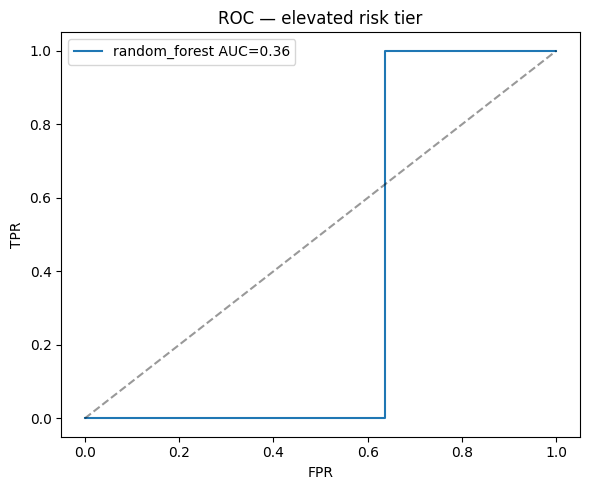

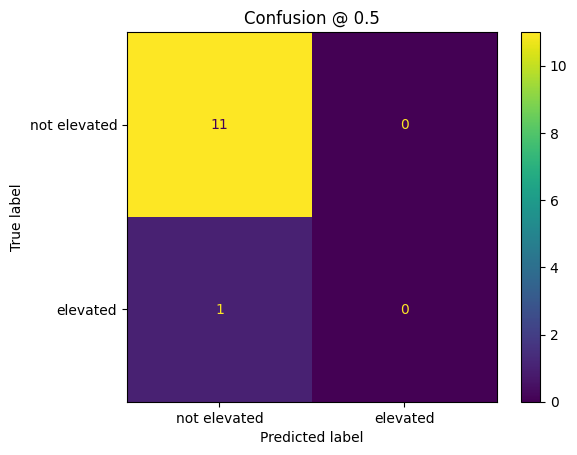


Fairness-style slice: test rows by case_category


,n,elevated_rate,mean_pred
case_category,,,
Abandoned,7,0.1429,0.0524
Foundling,2,0.0000,0.2786
Neglected,2,0.0000,0.0262
Surrendered,1,0.0000,0.2681


In [8]:
best_pipe = fitted[best_name]
proba = best_pipe.predict_proba(X_test)[:, 1]
y_hat = (proba >= 0.5).astype(int)
print(classification_report(y_test, y_hat, target_names=["not_elevated", "elevated"], zero_division=0))
print("ROC-AUC (holdout):", round(float(roc_auc_score(y_test, proba)), 3))

fpr, tpr, _ = roc_curve(y_test, proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{best_name} AUC={roc_auc_score(y_test, proba):.2f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC — elevated risk tier")
plt.legend()
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_hat, display_labels=["not elevated", "elevated"])
plt.title("Confusion @ 0.5")
plt.show()

ft = feat_test.copy()
ft["p_elevated"] = proba
if "case_category" in ft.columns:
    print("\nFairness-style slice: test rows by case_category")
    display(
        ft.groupby("case_category", dropna=False)
        .agg(n=("elevated_risk", "size"), elevated_rate=("elevated_risk", "mean"), mean_pred=("p_elevated", "mean"))
        .round(4)
    )

In [9]:
param_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [3, 5, None],
    "model__min_samples_leaf": [1, 2],
}
base_rf = Pipeline(
    [
        ("prep", clone(preprocess)),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
    ]
)
grid = GridSearchCV(base_rf, param_grid, scoring="roc_auc", cv=cv_sel, n_jobs=-1, refit=True)
grid.fit(X_train, y_train)
print("Best CV ROC-AUC:", round(float(grid.best_score_), 4), "params:", grid.best_params_)
tuned_proba = grid.predict_proba(X_test)[:, 1]
print("Holdout ROC-AUC (tuned RF):", round(float(roc_auc_score(y_test, tuned_proba)), 4))
best_deploy_pipe = grid.best_estimator_

Best CV ROC-AUC: 0.8861 params: {'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__n_estimators': 200}
Holdout ROC-AUC (tuned RF): 0.3636


## Phase 5b — Feature selection (Ch. 16)

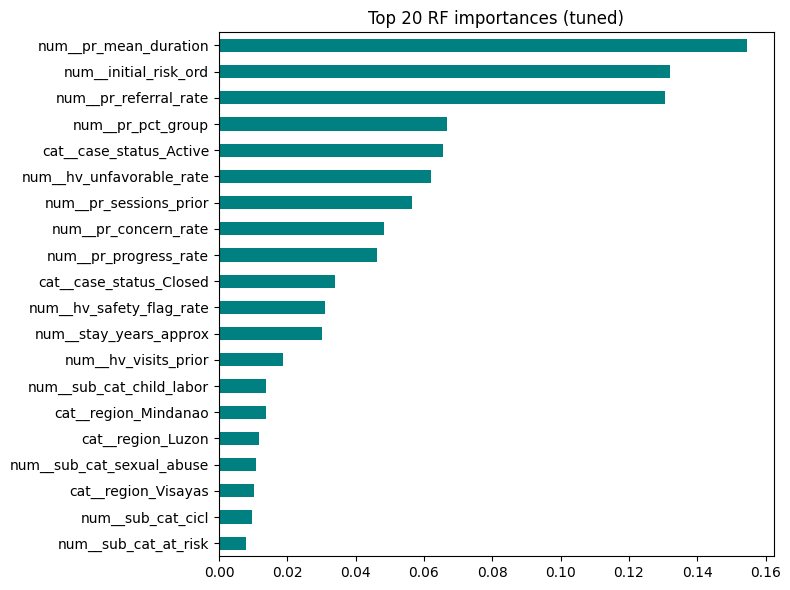

,importance
num__pr_mean_duration,0.154633
num__initial_risk_ord,0.132142
num__pr_referral_rate,0.130537
num__pr_pct_group,0.066740
cat__case_status_Active,0.065479
num__hv_unfavorable_rate,0.062087
num__pr_sessions_prior,0.056647
num__pr_concern_rate,0.048315
num__pr_progress_rate,0.046312
cat__case_status_Closed,0.034113


Features above median importance: 20 / 40


In [10]:
prep_fitted = best_deploy_pipe.named_steps["prep"]
model_fitted = best_deploy_pipe.named_steps["model"]
fnames = list(prep_fitted.get_feature_names_out())
imp = pd.Series(model_fitted.feature_importances_, index=fnames).sort_values(ascending=False).head(20)
imp.sort_values().plot(kind="barh", color="teal", figsize=(8, 6))
plt.title("Top 20 RF importances (tuned)")
plt.tight_layout()
plt.show()
display(imp.to_frame("importance"))
selector = SelectFromModel(model_fitted, prefit=True, threshold="median")
print("Features above median importance:", int(selector.get_support().sum()), "/", len(fnames))

## Phase 6 — Deployment (Ch. 17)

- **Artifact:** `resident_elevated_risk_pipeline.joblib` — tuned random forest pipeline for **staff-only** risk scores.
- **Integration:** Admin API e.g. `GET /api/residents/{id}/risk-score` batch-computed nightly from the same feature SQL/ETL as this notebook; or embed scores in **caseload** dashboard.
- **Governance:** Human override required; audit log when scores influence supervision meetings.

**Metadata** documents windows and columns for reproducibility.

In [11]:
metadata = {
    "pipeline": "resident_elevated_risk",
    "observation_date": str(obs_date.date()),
    "feature_window": [str(feature_start.date()), str(feature_end.date())],
    "gap_days_before_obs": gap_days,
    "label": "elevated_risk = 1 if current_risk_level in High/Critical",
    "numeric_features": num_cols,
    "categorical_features": cat_cols,
    "best_grid_params": grid.best_params_,
}

joblib.dump(best_deploy_pipe, SERIALIZED_DIR / "resident_elevated_risk_pipeline.joblib")
with open(SERIALIZED_DIR / "resident_elevated_risk_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
print("Saved pipeline + metadata to", SERIALIZED_DIR)

Saved pipeline + metadata to /Users/jooyoung/Downloads/intex2026/WinterIntex4-5/ml-pipelines/resident_case_progress/serialized_models


### Limitations

- **Tiny positive class** (~10%): metrics are unstable; prefer **qualitative** use of importances + staff review.
- **Label is administrative**, not a gold-standard clinical outcome.
- **30-day gap** reduces but does not eliminate alignment between sessions and risk updates.

**Next steps:** Link predictions to **intervention plan** actions in the web app; refresh features on a schedule aligned with supervision meetings.